In [13]:
from PIL import Image
import numpy as np

# Open the image file
img = Image.open('/content/clouds_lmh_2017080100.png')

# Convert the image to a NumPy array
img_array = np.array(img)

# Extract the red channel (assuming the image is RGB or RGBA)
# The red channel is typically the first channel (index 0)
red_channel = img_array[:, :, 0]

# Scale the red channel data to the range [0, 1]
# Assuming the original data is in the range [0, 255] (common for image data)
scaled_red_channel = red_channel / 255.0

# Display the shape of the scaled array and some values
print("Shape of the scaled red channel array:", scaled_red_channel.shape)
print("Scaled red channel array (first 5x5):")
display(scaled_red_channel[:5, :5])

Shape of the scaled red channel array: (721, 1440)
Scaled red channel array (first 5x5):


array([[0.98039216, 0.98039216, 0.98039216, 0.98039216, 0.98039216],
       [0.93333333, 0.9372549 , 0.9372549 , 0.9372549 , 0.9372549 ],
       [0.97254902, 0.97254902, 0.97254902, 0.97254902, 0.97647059],
       [0.99607843, 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ]])

In [16]:
scaled_red_channel = np.flipud(scaled_red_channel)

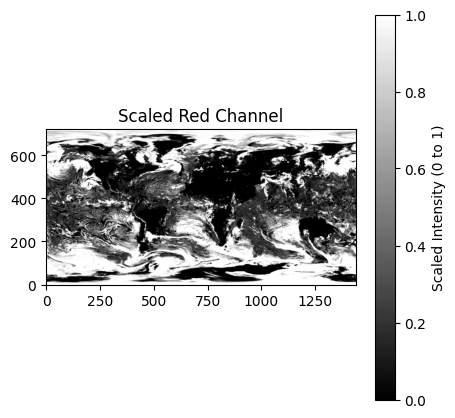

In [17]:
import matplotlib.pyplot as plt

# Create a 2D plot from the scaled red channel array
plt.figure(figsize=(5, 5))
plt.imshow(scaled_red_channel, cmap='gray', origin='lower')
plt.title('Scaled Red Channel')
plt.colorbar(label='Scaled Intensity (0 to 1)')
plt.show()

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider

lowBreakPoint = 0.75
highBreakPoint = 0.95

def update_plot(lowBreakPoint, highBreakPoint):
    # Create an empty color image array with the same shape as the scaled red channel, but with 3 channels for RGB
    color_image = np.zeros((scaled_red_channel.shape[0], scaled_red_channel.shape[1], 3), dtype=np.uint8)

    # Assign colors based on the thresholds
    # Red for values less than lowBreakPoint
    color_image[scaled_red_channel < lowBreakPoint] = [255, 0, 0]

    # Green for values between lowBreakPoint and highBreakPoint
    color_image[(scaled_red_channel >= lowBreakPoint) & (scaled_red_channel < highBreakPoint)] = [0, 255, 0]

    # Blue for values greater than or equal to highBreakPoint
    color_image[scaled_red_channel >= highBreakPoint] = [0, 0, 255]

    # Create a 2D plot from the color image array
    plt.figure(figsize=(10, 10))
    plt.imshow(color_image, origin='lower')
    plt.title('Color coded based on scaled red channel')
    plt.show()

# Create sliders for lowBreakPoint and highBreakPoint
low_slider = FloatSlider(min=0.0, max=1.0, step=0.01, value=lowBreakPoint, description='Low Breakpoint:')
high_slider = FloatSlider(min=0.0, max=1.0, step=0.01, value=highBreakPoint, description='High Breakpoint:')

# Use interact to link the sliders to the update_plot function
interact(update_plot, lowBreakPoint=low_slider, highBreakPoint=high_slider)

interactive(children=(FloatSlider(value=0.75, description='Low Breakpoint:', max=1.0, step=0.01), FloatSlider(…

<function __main__.update_plot(lowBreakPoint, highBreakPoint)>

In [22]:
def get_neighbors(arr, row_col):
    """
    Returns the 8 neighbors of a given cell in a 2D array in clockwise order.

    Args:
        arr (np.ndarray): The input 2D NumPy array.
        row_col (tuple): A tuple (row, col) representing the cell's indices.

    Returns:
        tuple: A tuple containing the indices of the 8 neighbors in clockwise order,
               starting from North and ending at Northwest. None is returned for
               neighbors that do not exist.
    """
    if row_col is None:
        return (None, None, None, None, None, None, None, None)

    rows, cols = arr.shape
    row, col = row_col

    neighbors = []

    # Define the relative indices for the 8 neighbors in clockwise order
    # (row_offset, col_offset)
    neighbor_offsets = [
        (-1, 0),  # North
        (-1, 1),  # Northeast
        (0, 1),   # East
        (1, 1),   # Southeast
        (1, 0),   # South
        (1, -1),  # Southwest
        (0, -1),  # West
        (-1, -1)  # Northwest
    ]

    for row_offset, col_offset in neighbor_offsets:
        neighbor_row = row + row_offset
        neighbor_col = col + col_offset

        # Check if the neighbor is within the array bounds
        if 0 <= neighbor_row < rows and 0 <= neighbor_col < cols:
            neighbors.append((neighbor_row, neighbor_col))
        else:
            neighbors.append(None)

    return tuple(neighbors)

# Example usage (assuming scaled_red_channel is your 2D array)
# You can replace (row, col) with the actual indices you want to test
# test_row_col = (100, 200)
# neighbor_indices = get_neighbors(scaled_red_channel, test_row_col)
# print(f"Neighbors of {test_row_col}: {neighbor_indices}")

# Example with None input
# neighbor_indices_none = get_neighbors(scaled_red_channel, None)
# print(f"Neighbors of None: {neighbor_indices_none}")

In [23]:
# Define a constant for the cloud core threshold
CLOUD_CORE_THRESHOLD = 0.95

# Get the indices where the scaled red channel is greater than the threshold
cloud_core_indices = np.where(scaled_red_channel > CLOUD_CORE_THRESHOLD)

# Combine the row and column indices into a list of tuples
cloud_core_locations = list(zip(cloud_core_indices[0], cloud_core_indices[1]))

# Display the number of cloud core locations found and the first few locations
print(f"Number of cloud core locations: {len(cloud_core_locations)}")
print("First 10 cloud core locations (row, col):")
display(cloud_core_locations[:10])

Number of cloud core locations: 258472
First 10 cloud core locations (row, col):


[(np.int64(0), np.int64(0)),
 (np.int64(0), np.int64(1)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(0), np.int64(4)),
 (np.int64(0), np.int64(5)),
 (np.int64(0), np.int64(6)),
 (np.int64(0), np.int64(7)),
 (np.int64(0), np.int64(8)),
 (np.int64(0), np.int64(9))]

BFS complete.
Number of visited locations: 319185
Number of neighboring cloud locations found: 60713


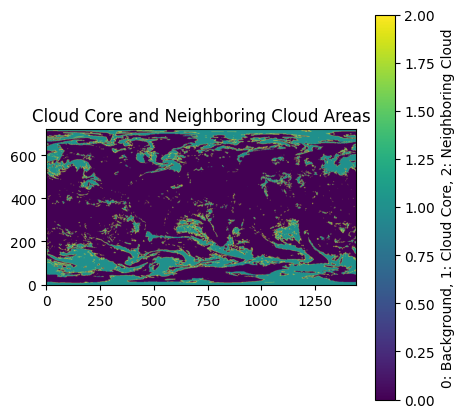

Unique values and their counts in the result array:


{np.uint8(0): np.int64(719055),
 np.uint8(1): np.int64(258472),
 np.uint8(2): np.int64(60713)}

In [29]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

# Define constants
CLOUD_CORE_THRESHOLD = 0.95
NEIGHBORING_CLOUD_THRESHOLD = 0.75

# Assuming scaled_red_channel is already loaded and available

# Get the indices where the scaled red channel is greater than the cloud core threshold
cloud_core_indices = np.where(scaled_red_channel > CLOUD_CORE_THRESHOLD)

# Combine the row and column indices into a list of tuples
cloud_core_locations = list(zip(cloud_core_indices[0], cloud_core_indices[1]))

# Initialize the queue with cloud_core_locations
queue = deque(cloud_core_locations)

# Initialize an empty set for visited locations
visited = set(cloud_core_locations) # Mark initial cloud cores as visited

# Initialize the result array with the same shape as scaled_red_channel, filled with zeros
result_array = np.zeros_like(scaled_red_channel, dtype=np.uint8)

# Mark initial cloud cores in the result array with 1
for row, col in cloud_core_locations:
    result_array[row, col] = 1

# Implement BFS loop
while queue:
    # Dequeue a location
    current_row, current_col = queue.popleft()

    # Get the 8 neighbors of the current location
    neighbors = get_neighbors(scaled_red_channel, (current_row, current_col))

    # Process neighbors
    for neighbor in neighbors:
        # Check if the neighbor is valid (not None)
        if neighbor is not None:
            neighbor_row, neighbor_col = neighbor

            # Check if the neighbor has not been visited
            if neighbor not in visited:
                # Check if the cloud cover at the neighbor's location is greater than the threshold
                if scaled_red_channel[neighbor_row, neighbor_col] > NEIGHBORING_CLOUD_THRESHOLD:
                    # Enqueue the neighbor
                    # queue.append(neighbor)
                    # Add the neighbor to the visited set
                    visited.add(neighbor)
                    # Set the corresponding element in result_array to 2
                    result_array[neighbor_row, neighbor_col] = 2

print("BFS complete.")
print("Number of visited locations:", len(visited))
print("Number of neighboring cloud locations found:", np.sum(result_array == 2))


# Display the result array
plt.figure(figsize=(5, 5))
plt.imshow(result_array, cmap='viridis', origin='lower') # Using viridis colormap to distinguish 0, 1, and 2
plt.title('Cloud Core and Neighboring Cloud Areas')
plt.colorbar(label='0: Background, 1: Cloud Core, 2: Neighboring Cloud')
plt.show()

# Display unique values and their counts in the result array
unique, counts = np.unique(result_array, return_counts=True)
print("Unique values and their counts in the result array:")
display(dict(zip(unique, counts)))

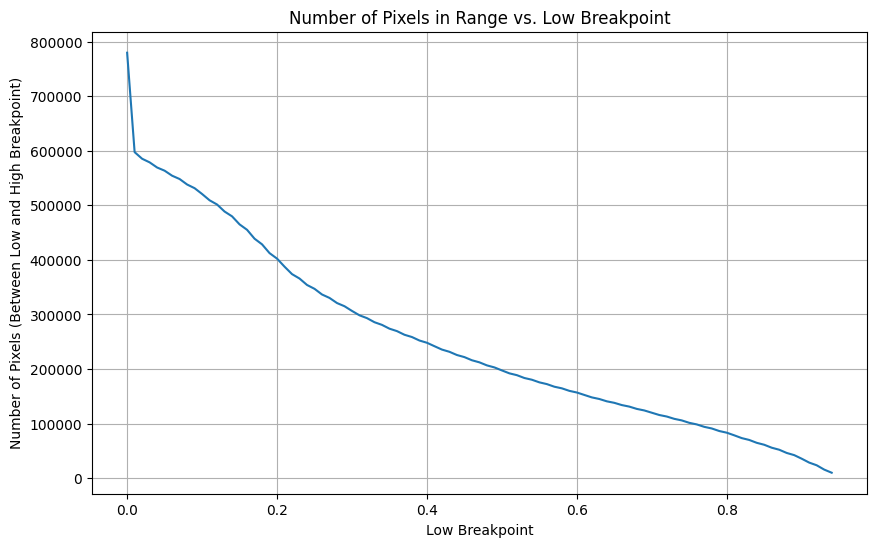

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Define the constant high breakpoint
highBreakPoint_constant = 0.95

# Define the range of low breakpoints to test
lowBreakPoints_to_test = np.arange(0, highBreakPoint_constant, 0.01) # Vary lowBreakPoint from 0 to 0.94 with a step of 0.01

# List to store the counts of pixels in the specified range
green_pixel_counts = []

# Iterate through each low breakpoint
for lowBreakPoint in lowBreakPoints_to_test:
    # Calculate the number of pixels where scaled_red_channel is between lowBreakPoint and highBreakPoint_constant
    count = np.sum((scaled_red_channel >= lowBreakPoint) & (scaled_red_channel < highBreakPoint_constant))
    green_pixel_counts.append(count)

# Create the line graph
plt.figure(figsize=(10, 6))
plt.plot(lowBreakPoints_to_test, green_pixel_counts)
plt.xlabel('Low Breakpoint')
plt.ylabel('Number of Pixels (Between Low and High Breakpoint)')
plt.title('Number of Pixels in Range vs. Low Breakpoint')
plt.grid(True)
plt.show()


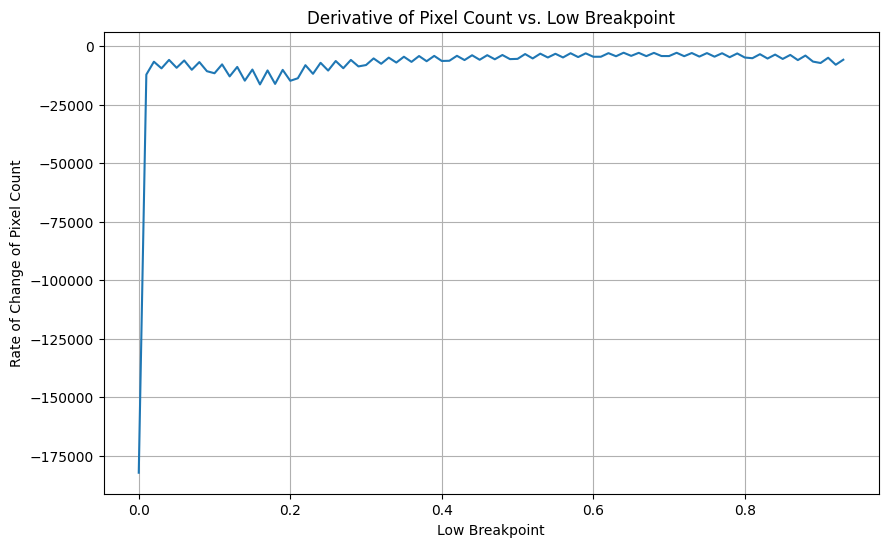

First 10 derivative values:


array([-182257,  -12107,   -6603,   -9440,   -5827,   -9196,   -6074,
        -10046,   -6761,  -10659])

In [37]:
# Calculate the derivative of the green pixel counts with respect to the low breakpoints
# Use np.diff to calculate the difference between consecutive elements
# The result will have one less element than the original arrays
derivative_counts = np.diff(green_pixel_counts)
derivative_lowBreakPoints = lowBreakPoints_to_test[:-1] # The x-values for the derivative are the starting points of the intervals

# Create the line graph of the derivative
plt.figure(figsize=(10, 6))
plt.plot(derivative_lowBreakPoints, derivative_counts)
plt.xlabel('Low Breakpoint')
plt.ylabel('Rate of Change of Pixel Count')
plt.title('Derivative of Pixel Count vs. Low Breakpoint')
plt.grid(True)
plt.show()

# Display the first few derivative values
print("First 10 derivative values:")
display(derivative_counts[:10])